# **Aggregation Analysis and Trends:** 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [32]:
data= pd.read_csv("data.csv")
data.shape

(42468, 14)

In [33]:
data.head(2)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


### **1. Average Hours per Week by Country:**

Objective: Check if people in some countries work more than others.
How: Group by native-country and calculate mean hours-per-week.

In [34]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [48]:
dass= data.groupby(by= "native-country")["hours-per-week"].mean().reset_index().sort_values(by= "hours-per-week", ascending= False)
dass

,native-country,hours-per-week
11,Greece,46.897959
37,Thailand,44.700000
19,Iran,42.949153
35,South,42.852174
9,France,42.789474
20,Ireland,42.638889
23,Japan,42.282609
32,Portugal,42.238806
0,Cambodia,42.035714
8,England,41.937008


In [49]:
dass.head(4)

,native-country,hours-per-week
11,Greece,46.897959
37,Thailand,44.700000
19,Iran,42.949153
35,South,42.852174


**Peoples from countries having longest work weeks (top 10):**

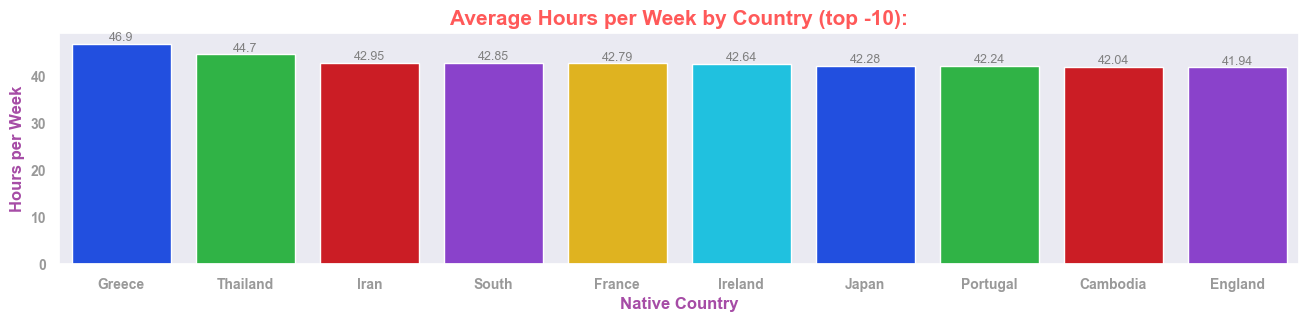

In [52]:
dassi= dass.head(10)
plt.figure(figsize= (16, 3))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(x= dassi["native-country"], y= dassi["hours-per-week"], palette= "bright6")
# add annotations
for i in range(len(dassi)):
    plt.text(x= i, y= dassi["hours-per-week"].iloc[i], s= dassi["hours-per-week"].iloc[i].round(2), ha= "center", va= "bottom", color= "gray", fontsize= 9) 

plt.title("Average Hours per Week by Country (top -10):", fontsize= 15, fontweight= "bold", color= "red", alpha= 0.65)
plt.xlabel("Native Country", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Hours per Week", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.xticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.yticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.show()

* Greece has the highest average weekly work hours.

* European countries dominate the top 10 most working countries.

* Asian countries like Thailand and Japan show high work hours.

* Work hour differences among countries are relatively small.

* Developed and developing countries show similar work patterns.

* Top five countries exceed 42.5 hours weekly on average.

* Greece stands out with significantly higher work hours.

* Western countries like France and England work fewer hours.

* There's a narrow range between most countries' work hours.

* Cultural or economic factors may drive these work patterns.

**Contries havaing lowest work-weeks (10 countries):**

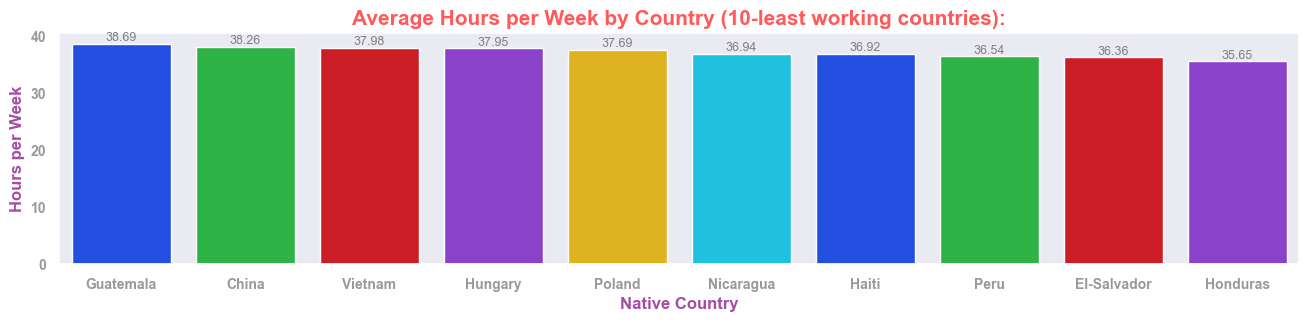

In [53]:
daio= dass.tail(10)
plt.figure(figsize= (16, 3))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(x= daio["native-country"], y= daio["hours-per-week"], palette= "bright6")
# add annotations
for i in range(len(daio)):
    plt.text(x= i, y= daio["hours-per-week"].iloc[i], s= daio["hours-per-week"].iloc[i].round(2), ha= "center", va= "bottom", color= "gray", fontsize= 9) 

plt.title("Average Hours per Week by Country (10-least working countries):", fontsize= 15, fontweight= "bold", color= "red", alpha= 0.65)
plt.xlabel("Native Country", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Hours per Week", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.xticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.yticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.show()

* Honduras has the lowest average weekly work hours overall.

* All countries in this group work under 39 hours weekly.

* Work hour differences are narrow across these 10 countries.

* Central American countries dominate the least-working list.

* Eastern Europe also appears with Hungary and Poland included.

* China and Vietnam have relatively low average work hours.

* No Western European countries are among the least-working.

* The gap from `highest (Greece)` to `lowest (Honduras)` is `\~11 hours` whic is more than 2 hrs per day in difference considering 5-days work week. 

----
----
----
-----
----

### **Income by Country and Gender:**

Objective: Understand if gender pay gaps exist in different countries.
How: Multi-index group by native-country and gender, compare salary.

In [54]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [55]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [60]:
asx= data[["native-country", "gender", "salary"]].value_counts().reset_index()
asx

,native-country,gender,salary,count
0,United-States,Male,<=50K,16701
1,United-States,Female,<=50K,11334
2,United-States,Male,>50K,7889
3,United-States,Female,>50K,1568
4,Mexico,Male,<=50K,670
...,...,...,...,...
155,Nicaragua,Female,>50K,1
156,Thailand,Female,>50K,1
157,Scotland,Female,>50K,1
158,Vietnam,Female,>50K,1
